In [30]:
# Step 1A — import libraries

import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [31]:
# Step 1B — define file paths from your local machine

from pathlib import Path

# OPTION 1: if your notebook is in the same folder as all files
base = Path.cwd()

# OPTION 2: if all files are inside Downloads, use this instead:
# base = Path.home() / "Downloads"

parquet_file = base / "northeast_c2c_all_modes.parquet"
fips_file = base / "county_fips_lookup_clean.xlsx"
ne_boundary_file = base / "Northeastern_States_County_Boundary_Set_2681780721479727903.csv"

county_shp = base / "cb_2024_us_county_5m.shp"
state_shp = base / "cb_2024_us_state_5m.shp"

seaports_file = base / "NTAD_Commercial_Strategic_Seaports_-1568015396490297502.csv"
border_file = base / "Border_Crossing_Entry_Data.csv"
aviation_file = base / "NTAD_Aviation_Facilities_-6638870864286043795.csv"
air_truck_file = base / "NTAD_Intermodal_Freight_Facilities_Air_to_Truck_1517463693399051200.csv"
rail_yards_file = base / "NTAD_Rail_Yards_5262064445198367435.csv"
rail_lines_file = base / "NTAD_North_American_Rail_Network_Lines_Class_I_Railroads_5498482498756130206.csv"
marad_gateways_file = base / "NTAD_DOT_MARAD_Gateway_Regions_-2354880427640400154.csv"

flow_type_file = base / "breakdown_by_flow_type.csv"
mode_file = base / "breakdown_by_mode.csv"
trade_type_file = base / "breakdown_by_trade_type.csv"
state_summary_file = base / "ne_state_summary.csv"
top_orig_file = base / "top50_origin_counties.csv"
top_dest_file = base / "top50_dest_counties.csv"


In [32]:
files_to_check = [
    parquet_file, fips_file, ne_boundary_file, county_shp, state_shp,
    seaports_file, border_file, aviation_file, air_truck_file,
    rail_yards_file, rail_lines_file, marad_gateways_file,
    flow_type_file, mode_file, trade_type_file, state_summary_file,
    top_orig_file, top_dest_file
]

for f in files_to_check:
    print(f"{f.name}: {'FOUND' if f.exists() else 'NOT FOUND'}")

northeast_c2c_all_modes.parquet: FOUND
county_fips_lookup_clean.xlsx: FOUND
Northeastern_States_County_Boundary_Set_2681780721479727903.csv: FOUND
cb_2024_us_county_5m.shp: FOUND
cb_2024_us_state_5m.shp: FOUND
NTAD_Commercial_Strategic_Seaports_-1568015396490297502.csv: FOUND
Border_Crossing_Entry_Data.csv: FOUND
NTAD_Aviation_Facilities_-6638870864286043795.csv: FOUND
NTAD_Intermodal_Freight_Facilities_Air_to_Truck_1517463693399051200.csv: FOUND
NTAD_Rail_Yards_5262064445198367435.csv: FOUND
NTAD_North_American_Rail_Network_Lines_Class_I_Railroads_5498482498756130206.csv: FOUND
NTAD_DOT_MARAD_Gateway_Regions_-2354880427640400154.csv: FOUND
breakdown_by_flow_type.csv: FOUND
breakdown_by_mode.csv: FOUND
breakdown_by_trade_type.csv: FOUND
ne_state_summary.csv: FOUND
top50_origin_counties.csv: FOUND
top50_dest_counties.csv: FOUND


In [33]:
from pathlib import Path
base = Path.home() / "Downloads"
print(base)

C:\Users\schaubey8\Downloads


In [34]:
# Step 1C — read the main files

flows = pd.read_parquet(parquet_file)
fips_lookup = pd.read_excel(fips_file)
ne_boundary = pd.read_csv(ne_boundary_file)

counties = gpd.read_file(county_shp)
states = gpd.read_file(state_shp)

seaports = pd.read_csv(seaports_file)
borders = pd.read_csv(border_file)
aviation = pd.read_csv(aviation_file)
air_truck = pd.read_csv(air_truck_file)
rail_yards = pd.read_csv(rail_yards_file)
rail_lines = pd.read_csv(rail_lines_file)
marad_gateways = pd.read_csv(marad_gateways_file)

flow_type = pd.read_csv(flow_type_file)
mode_breakdown = pd.read_csv(mode_file)
trade_breakdown = pd.read_csv(trade_type_file)
ne_state_summary = pd.read_csv(state_summary_file)
top_orig = pd.read_csv(top_orig_file)
top_dest = pd.read_csv(top_dest_file)

C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\64555233.py:12: DtypeWarning: Columns (45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  aviation = pd.read_csv(aviation_file)
C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\64555233.py:15: DtypeWarning: Columns (4,12,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  rail_lines = pd.read_csv(rail_lines_file)


In [35]:
# Step 1D — inspect shapes of all files

datasets = {
    "flows": flows,
    "fips_lookup": fips_lookup,
    "ne_boundary": ne_boundary,
    "counties": counties,
    "states": states,
    "seaports": seaports,
    "borders": borders,
    "aviation": aviation,
    "air_truck": air_truck,
    "rail_yards": rail_yards,
    "rail_lines": rail_lines,
    "marad_gateways": marad_gateways,
    "flow_type": flow_type,
    "mode_breakdown": mode_breakdown,
    "trade_breakdown": trade_breakdown,
    "ne_state_summary": ne_state_summary,
    "top_orig": top_orig,
    "top_dest": top_dest
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

flows: (33404629, 7)
fips_lookup: (3153, 6)
ne_boundary: (10045, 4)
counties: (3235, 13)
states: (56, 10)
seaports: (18, 11)
borders: (273391, 10)
aviation: (19707, 93)
air_truck: (404, 7)
rail_yards: (2676, 6)
rail_lines: (84639, 34)
marad_gateways: (9, 14)
flow_type: (3, 5)
mode_breakdown: (5, 5)
trade_breakdown: (3, 5)
ne_state_summary: (14, 6)
top_orig: (50, 6)
top_dest: (50, 6)


In [36]:
# Step 1E — inspect column names

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


flows
['origin_county_fips', 'dest_county_fips', 'mode', 'sctgG5', 'trade_type', 'tons_2025', 'tons_2030']

fips_lookup
['state_name', 'county_name', 'state_abbr', 'state_fips', 'county_fips', 'is_northeast']

ne_boundary
['OBJECTID', 'BOUNDARY', 'DATA_SRC', 'Shape__Length']

counties
['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']

states
['STATEFP', 'STATENS', 'GEOIDFQ', 'GEOID', 'STUSPS', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']

seaports
['OBJECTID', 'latitude', 'longitude', 'port_name', 'total', 'domestic', 'foreign', 'imports', 'exports', 'x', 'y']

borders
['Port Name', 'State', 'Port Code', 'Border', 'Date', 'Measure', 'Value', 'Latitude', 'Longitude', 'Point']

aviation
['OBJECTID', 'EFF_DATE', 'SITE_NO', 'SITE_TYPE_CODE', 'STATE_CODE', 'ARPT_ID', 'CITY', 'COUNTRY_CODE', 'REGION_CODE', 'ADO_CODE', 'STATE_NAME', 'COUNTY_NAME', 'COUNTY_ASSOC_STATE', 'ARPT_NAME', 'OWNERSHIP_TYPE_CODE

In [37]:
# Step 1F — inspect first few rows of the most important files

print("FLOWS")
display(flows.head())

print("FIPS LOOKUP")
display(fips_lookup.head())

print("COUNTIES")
display(counties.head())

print("SEAPORTS")
display(seaports.head())

print("BORDERS")
display(borders.head())

print("AVIATION")
display(aviation.head())

print("AIR_TRUCK")
display(air_truck.head())

FLOWS


,origin_county_fips,dest_county_fips,mode,sctgG5,trade_type,tons_2025,tons_2030
0,1001,9110,5,sctg0109,1,0.000033,0.000028
1,1001,9110,5,sctg2033,1,0.000717,0.000979
2,1001,9110,5,sctg3499,1,0.000180,0.000272
3,1001,9110,11,sctg0109,1,0.004891,0.004869
4,1001,9110,11,sctg2033,1,0.064706,0.096066


FIPS LOOKUP


,state_name,county_name,state_abbr,state_fips,county_fips,is_northeast
0,ALABAMA,AUTAUGA,AL,1,1001,0
1,ALABAMA,BALDWIN,AL,1,1003,0
2,ALABAMA,BARBOUR,AL,1,1005,0
3,ALABAMA,BIBB,AL,1,1007,0
4,ALABAMA,BLOUNT,AL,1,1009,0


COUNTIES


...

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Hidalgo,Texas,2305,US-Mexico Border,Jan 2026,Buses,640,26.095,-98.271,POINT (-98.271092 26.095032)
1,Brownsville,Texas,2301,US-Mexico Border,Jan 2026,Buses,264,25.952,-97.401,POINT (-97.40067 25.95155)
2,Warroad,Minnesota,3423,US-Canada Border,Dec 2025,Buses,9,48.999,-95.377,POINT (-95.376555 48.999)
3,Alcan,Alaska,3104,US-Canada Border,Nov 2025,Trucks,547,62.615,-141.001,POINT (-141.001444 62.614961)
4,Laredo,Texas,2304,US-Mexico Border,Jul 2025,Buses,2546,27.500,-99.507,POINT (-99.507412 27.499561)


AVIATION


,OBJECTID,EFF_DATE,SITE_NO,SITE_TYPE_CODE,STATE_CODE,ARPT_ID,CITY,COUNTRY_CODE,REGION_CODE,ADO_CODE,STATE_NAME,COUNTY_NAME,COUNTY_ASSOC_STATE,ARPT_NAME,OWNERSHIP_TYPE_CODE,FACILITY_USE_CODE,LAT_DEG,LAT_MIN,LAT_SEC,LAT_HEMIS,LAT_DECIMAL,LONG_DEG,LONG_MIN,LONG_SEC,LONG_HEMIS,LONG_DECIMAL,SURVEY_METHOD_CODE,ELEV,ELEV_METHOD_CODE,MAG_VARN,MAG_HEMIS,MAG_VARN_YEAR,TPA,CHART_NAME,DIST_CITY_TO_AIRPORT,DIRECTION_CODE,ACREAGE,RESP_ARTCC_ID,COMPUTER_ID,ARTCC_NAME,FSS_ON_ARPT_FLAG,FSS_ID,FSS_NAME,PHONE_NO,TOLL_FREE_NO,ALT_FSS_ID,ALT_FSS_NAME,ALT_TOLL_FREE_NO,NOTAM_ID,NOTAM_FLAG,ACTIVATION_DATE,ARPT_STATUS,FAR_139_TYPE_CODE,FAR_139_CARRIER_SER_CODE,ARFF_CERT_TYPE_DATE,NASP_CODE,ASP_ANLYS_DTRM_CODE,CUST_FLAG,LNDG_RIGHTS_FLAG,JOINT_USE_FLAG,MIL_LNDG_FLAG,INSPECT_METHOD_CODE,INSPECTOR_CODE,LAST_INSPECTION,LAST_INFO_RESPONSE,FUEL_TYPES,AIRFRAME_REPAIR_SER_CODE,PWR_PLANT_REPAIR_SER,BOTTLED_OXY_TYPE,BULK_OXY_TYPE,LGT_SKED,BCN_LGT_SKED,TWR_TYPE_CODE,SEG_CIRCLE_MKR_FLAG,BCN_LENS_COLOR,LNDG_FEE_FLAG,MEDICAL_USE_FLAG,ARPT_PSN_SOURCE,POSITION_SRC_DATE,ARPT_ELEV_SOURCE,ELEVATION_SRC_DATE,CONTR_FUEL_AVBL,TRNS_STRG_BUOY_FLAG,TRNS_STRG_HGR_FLAG,TRNS_STRG_TIE_FLAG,OTHER_SERVICES,WIND_INDCR_FLAG,ICAO_ID,MIN_OP_NETWORK,USER_FEE_FLAG,CTA,x,y
0,1,2025/12/25,103.00,A,AL,0J0,ABBEVILLE,US,ASO,JAN,ALABAMA,HENRY,AL,ABBEVILLE MUNI,PU,PU,31,36,6.193,N,31.601720,85,14,18.761,W,-85.238545,E,468.3,E,1.0,W,1985.0,NaN,NEW ORLEANS,3.0,N,36.0,ZJX,ZCJ,JACKSONVILLE,N,ANB,ANNISTON,NaN,1-800-WX-BRIEF,NaN,NaN,NaN,ANB,Y,1959/08,O,NaN,NaN,NaN,N,NOT ANALYZED,NaN,NaN,NaN,NaN,S,S,2023/05/26,NaN,NaN,NONE,NONE,NaN,NaN,SEE RMK,SS-SR,NON-ATCT,N,WG,N,NaN,3RD PARTY SURVEY,2025/06/17,3RD PARTY SURVEY,2025/06/17,NaN,NaN,NaN,Y,NaN,Y-L,NaN,N,NaN,NaN,-9.488711e+06,3.711143e+06
1,2,2025/12/25,106.00,A,AL,2A8,ADDISON,US,ASO,JAN,ALABAMA,WINSTON,AL,ADDISON MUNI,PU,PU,34,13,1.710,N,34.217142,87,9,29.370,W,-87.158158,E,786.0,E,0.0,E,1980.0,NaN,ATLANTA,1.0,NE,37.0,ZME,ZCM,MEMPHIS,NaN,ANB,ANNISTON,NaN,1-800-WX-BRIEF,NaN,NaN,NaN,ANB,Y,1986/12,O,NaN,NaN,NaN,NaN,CONDL,NaN,NaN,NaN,NaN,S,S,2023/05/10,1988/01/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NON-ATCT,N,NaN,NaN,NaN,FAA-EST,2011/08/08,NaN,NaN,NaN,NaN,NaN,N,NaN,Y,NaN,N,NaN,NaN,-9.702402e+06,4.057996e+06
2,3,2025/12/25,108.00,A,AL,AL03,AKRON,US,ASO,JAN,ALABAMA,HALE,AL,STRICKLAND/SMALLEY FLD,PR,PR,32,50,51.000,N,32.847500,87,42,50.000,W,-87.713889,E,369.0,E,NaN,NaN,NaN,NaN,ATLANTA,3.0,SE,NaN,ZTL,ZCT,ATLANTA,NaN,MKL,JACKSON,NaN,1-800-WX-BRIEF,NaN,NaN,NaN,NaN,NaN,2007/11,O,NaN,NaN,NaN,NaN,CONDL,NaN,NaN,NaN,NaN,2,N,NaN,2021/12/13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NON-ATCT,NaN,NaN,NaN,NaN,DOD (NGA),2014/07/07,OWNER,2008/04/29,NaN,NaN,NaN,NaN,NaN,Y,NaN,N,NaN,NaN,-9.764265e+06,3.875080e+06
3,4,2025/12/25,110.00,A,AL,EET,ALABASTER,US,ASO,JAN,ALABAMA,SHELBY,AL,SHELBY COUNTY,PU,PU,33,10,40.000,N,33.177778,86,46,59.600,W,-86.783222,E,585.6,S,3.0,W,2010.0,NaN,ATLANTA,4.0,SE,125.0,ZTL,ZCT,ATLANTA,N,ANB,ANNISTON,NaN,1-800-WX-BRIEF,NaN,NaN,NaN,EET,Y,1965/04,O,NaN,NaN,NaN,NGY,NO OBJECTION,N,N,N,Y,S,S,2025/08/22,NaN,"100LL,A+",MAJOR,MAJOR,NONE,NONE,SEE RMK,SS-SR,NON-ATCT,Y,WG,N,NaN,3RD PARTY SURVEY,2008/10/12,3RD PARTY SURVEY,2008/10/12,NaN,NaN,NaN,Y,"INSTR,RNTL,SALES",Y-L,KEET,N,NaN,NaN,-9.660664e+06,3.918925e+06
4,5,2025/12/25,110.01,H,AL,AL39,ALABASTER,US,ASO,JAN,ALABAMA,SHELBY,AL,SHELBY MEDICAL CENTER,PR,PR,33,15,8.000,N,33.252222,86,48,44.000,W,-86.812222,E,510.0,E,0.0,E,1985.0,NaN,ATLANTA,0.0,NE,NaN,ZTL,ZCT,ATLANTA,N,ANB,ANNISTON,NaN,1-800-WX-BRIEF,NaN,NaN,NaN,NaN,N,1982/08,O,NaN,NaN,NaN,NaN,CONDL,NaN,NaN,NaN,NaN,2,N,NaN,2022/09/26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NON-ATCT,N,NaN,N,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,N,NaN,NaN,-9.663892e+06,3.928830e+06


AIR_TRUCK


,OBJECTID,LOCID,FACILITY_C,DATE,EST_AREA,x,y
0,1,PIT,Delta Air Lines; United Parcel Service,09/2018,74000,-80.239910,40.505116
1,2,PIT,Federal Express,09/2018,73000,-80.237486,40.504440
2,3,PIT,,09/2018,65000,-80.234218,40.504221
3,4,PIT,,09/2018,55000,-80.219727,40.496006
4,5,RDU,Federal Express,09/2018,63000,-78.776205,35.889812


In [38]:
# Step 2A — standardize FIPS codes as 5-digit strings

flows["origin_county_fips"] = flows["origin_county_fips"].astype(str).str.zfill(5)
flows["dest_county_fips"]   = flows["dest_county_fips"].astype(str).str.zfill(5)

fips_lookup["county_fips"] = fips_lookup["county_fips"].astype(str).str.zfill(5)
fips_lookup["state_fips"]  = fips_lookup["state_fips"].astype(str).str.zfill(2)

counties["GEOID"] = counties["GEOID"].astype(str).str.zfill(5)

print(flows[["origin_county_fips", "dest_county_fips"]].head())
print(fips_lookup[["state_abbr", "county_fips"]].head())
print(counties[["GEOID", "STATE_NAME", "STUSPS"]].head())

  origin_county_fips dest_county_fips
0              01001            09110
1              01001            09110
2              01001            09110
3              01001            09110
4              01001            09110
  state_abbr county_fips
0         AL       01001
1         AL       01003
2         AL       01005
3         AL       01007
4         AL       01009
   GEOID    STATE_NAME STUSPS
0  13101       Georgia     GA
1  18167       Indiana     IN
2  23031         Maine     ME
3  27031     Minnesota     MN
4  38013  North Dakota     ND


In [39]:
# Step 2B — Northeast megaregion states from the casework

northeast_states = [
    "WV", "VA", "MD", "DE", "DC",
    "PA", "NY", "NJ", "CT", "MA",
    "NH", "VT", "ME", "RI"
]

print("Northeast states:", northeast_states)
print("Count:", len(northeast_states))

Northeast states: ['WV', 'VA', 'MD', 'DE', 'DC', 'PA', 'NY', 'NJ', 'CT', 'MA', 'NH', 'VT', 'ME', 'RI']
Count: 14


In [40]:
# Step 2C — Northeast counties from lookup table

ne_counties_lookup = fips_lookup[fips_lookup["state_abbr"].isin(northeast_states)].copy()

print("Number of Northeast counties in lookup:", len(ne_counties_lookup))
display(ne_counties_lookup.head())

Number of Northeast counties in lookup: 435


,state_name,county_name,state_abbr,state_fips,county_fips,is_northeast
315,CONNECTICUT,FAIRFIELD,CT,09,09001,1
316,CONNECTICUT,HARTFORD,CT,09,09003,1
317,CONNECTICUT,LITCHFIELD,CT,09,09005,1
318,CONNECTICUT,MIDDLESEX,CT,09,09007,1
319,CONNECTICUT,NEW HAVEN,CT,09,09009,1


In [41]:
# Step 2D — create a county FIPS set for fast filtering

ne_fips_set = set(ne_counties_lookup["county_fips"].unique())

print("Unique Northeast county FIPS count:", len(ne_fips_set))
print("Sample Northeast county FIPS:", list(sorted(ne_fips_set))[:15])

Unique Northeast county FIPS count: 435
Sample Northeast county FIPS: ['09001', '09003', '09005', '09007', '09009', '09011', '09013', '09015', '10001', '10003', '10005', '11001', '23001', '23003', '23005']


In [42]:
# Step 2E — tag origin/destination as Northeast or not

flows["origin_in_ne"] = flows["origin_county_fips"].isin(ne_fips_set).to_numpy()
flows["dest_in_ne"]   = flows["dest_county_fips"].isin(ne_fips_set).to_numpy()

display(flows[["origin_county_fips", "dest_county_fips", "origin_in_ne", "dest_in_ne"]].head())

,origin_county_fips,dest_county_fips,origin_in_ne,dest_in_ne
0,01001,09110,False,False
1,01001,09110,False,False
2,01001,09110,False,False
3,01001,09110,False,False
4,01001,09110,False,False


In [43]:
print(flows.shape)

(33404629, 9)


In [44]:
# Step 2F + 2G — create a smaller external-flows dataframe fast

cols_needed = [
    "origin_county_fips",
    "dest_county_fips",
    "mode",
    "sctgG5",
    "trade_type",
    "tons_2025",
    "tons_2030",
    "origin_in_ne",
    "dest_in_ne"
]

flows_small = flows[cols_needed].copy()

flows_small["ne_flow_type"] = np.select(
    [
        flows_small["origin_in_ne"] & flows_small["dest_in_ne"],
        (~flows_small["origin_in_ne"]) & flows_small["dest_in_ne"],
        flows_small["origin_in_ne"] & (~flows_small["dest_in_ne"])
    ],
    [
        "internal",
        "inbound",
        "outbound"
    ],
    default="outside_outside"
)

external_flows = flows_small[
    flows_small["ne_flow_type"].isin(["inbound", "outbound"])
].copy()

print("flows_small shape:", flows_small.shape)
print("external_flows shape:", external_flows.shape)
print(external_flows["ne_flow_type"].value_counts())

flows_small shape: (33404629, 10)
external_flows shape: (30004042, 10)
ne_flow_type
inbound     15019773
outbound    14984269
Name: count, dtype: int64


In [45]:
import gc

del flows_small
gc.collect()

532

In [46]:
del flows
gc.collect()

0

In [47]:
# Step 2H — enrich external flows with county and state names

lookup_small = fips_lookup[[
    "county_fips", "county_name", "state_name", "state_abbr", "is_northeast"
]].copy()

origin_lookup = lookup_small.rename(columns={
    "county_fips": "origin_county_fips",
    "county_name": "origin_county_name",
    "state_name": "origin_state_name",
    "state_abbr": "origin_state_abbr",
    "is_northeast": "origin_lookup_ne"
})

dest_lookup = lookup_small.rename(columns={
    "county_fips": "dest_county_fips",
    "county_name": "dest_county_name",
    "state_name": "dest_state_name",
    "state_abbr": "dest_state_abbr",
    "is_northeast": "dest_lookup_ne"
})

external_flows = external_flows.merge(origin_lookup, on="origin_county_fips", how="left")
external_flows = external_flows.merge(dest_lookup, on="dest_county_fips", how="left")

print(external_flows.shape)
display(external_flows.head())

(30004042, 18)


,origin_county_fips,dest_county_fips,mode,sctgG5,trade_type,tons_2025,tons_2030,origin_in_ne,dest_in_ne,ne_flow_type,origin_county_name,origin_state_name,origin_state_abbr,origin_lookup_ne,dest_county_name,dest_state_name,dest_state_abbr,dest_lookup_ne
0,01001,10001,2,sctg2033,3,0.001231,0.007385,False,True,inbound,AUTAUGA,ALABAMA,AL,0.0,KENT,DELAWARE,DE,1.0
1,01001,10001,2,sctg3499,3,0.000100,0.000358,False,True,inbound,AUTAUGA,ALABAMA,AL,0.0,KENT,DELAWARE,DE,1.0
2,01001,10001,5,sctg2033,1,0.390588,0.503549,False,True,inbound,AUTAUGA,ALABAMA,AL,0.0,KENT,DELAWARE,DE,1.0
3,01001,10001,5,sctg2033,3,0.000036,0.000218,False,True,inbound,AUTAUGA,ALABAMA,AL,0.0,KENT,DELAWARE,DE,1.0
4,01001,10001,5,sctg3499,1,0.000114,0.000155,False,True,inbound,AUTAUGA,ALABAMA,AL,0.0,KENT,DELAWARE,DE,1.0


In [48]:
print(external_flows.columns.tolist())

['origin_county_fips', 'dest_county_fips', 'mode', 'sctgG5', 'trade_type', 'tons_2025', 'tons_2030', 'origin_in_ne', 'dest_in_ne', 'ne_flow_type', 'origin_county_name', 'origin_state_name', 'origin_state_abbr', 'origin_lookup_ne', 'dest_county_name', 'dest_state_name', 'dest_state_abbr', 'dest_lookup_ne']


In [50]:
# Step 3A — build compact Task 2 dataframe from already-clean external_flows

task2_flows = external_flows[
    [
        "origin_county_fips",
        "dest_county_fips",
        "mode",
        "sctgG5",
        "trade_type",
        "tons_2025",
        "tons_2030",
        "ne_flow_type",
        "origin_county_name",
        "origin_state_name",
        "origin_state_abbr",
        "dest_county_name",
        "dest_state_name",
        "dest_state_abbr",
    ]
].copy()

# reduce memory
task2_flows["mode"] = pd.to_numeric(task2_flows["mode"], downcast="integer")
task2_flows["trade_type"] = pd.to_numeric(task2_flows["trade_type"], downcast="integer")
task2_flows["tons_2025"] = pd.to_numeric(task2_flows["tons_2025"], downcast="float")
task2_flows["tons_2030"] = pd.to_numeric(task2_flows["tons_2030"], downcast="float")

for col in [
    "sctgG5",
    "ne_flow_type",
    "origin_county_name",
    "origin_state_name",
    "origin_state_abbr",
    "dest_county_name",
    "dest_state_name",
    "dest_state_abbr",
]:
    task2_flows[col] = task2_flows[col].astype("category")

print("task2_flows shape:", task2_flows.shape)
print(task2_flows.memory_usage(deep=True).sum() / 1024**2, "MB")
display(task2_flows.head())

task2_flows shape: (30004042, 14)
3662.9444484710693 MB


,origin_county_fips,dest_county_fips,mode,sctgG5,trade_type,tons_2025,tons_2030,ne_flow_type,origin_county_name,origin_state_name,origin_state_abbr,dest_county_name,dest_state_name,dest_state_abbr
0,01001,10001,2,sctg2033,3,0.001231,0.007385,inbound,AUTAUGA,ALABAMA,AL,KENT,DELAWARE,DE
1,01001,10001,2,sctg3499,3,0.000100,0.000358,inbound,AUTAUGA,ALABAMA,AL,KENT,DELAWARE,DE
2,01001,10001,5,sctg2033,1,0.390588,0.503549,inbound,AUTAUGA,ALABAMA,AL,KENT,DELAWARE,DE
3,01001,10001,5,sctg2033,3,0.000036,0.000218,inbound,AUTAUGA,ALABAMA,AL,KENT,DELAWARE,DE
4,01001,10001,5,sctg3499,1,0.000114,0.000155,inbound,AUTAUGA,ALABAMA,AL,KENT,DELAWARE,DE


In [51]:
import gc

del external_flows
gc.collect()

656

In [53]:
task2_flows.to_parquet("task2_flows_compact.parquet", index=False)
print("Saved: task2_flows_compact.parquet")

Saved: task2_flows_compact.parquet


In [54]:
print("Inbound / outbound tonnage summary:")
display(
    task2_flows.groupby("ne_flow_type", as_index=False)[["tons_2025", "tons_2030"]].sum()
)

print("\nTop 15 outside origin states feeding the Northeast:")
display(
    task2_flows[task2_flows["ne_flow_type"] == "inbound"]
    .groupby("origin_state_abbr", as_index=False)[["tons_2025", "tons_2030"]]
    .sum()
    .sort_values("tons_2025", ascending=False)
    .head(15)
)

print("\nTop 15 outside destination states served from the Northeast:")
display(
    task2_flows[task2_flows["ne_flow_type"] == "outbound"]
    .groupby("dest_state_abbr", as_index=False)[["tons_2025", "tons_2030"]]
    .sum()
    .sort_values("tons_2025", ascending=False)
    .head(15)
)

Inbound / outbound tonnage summary:


C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\3974387852.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  task2_flows.groupby("ne_flow_type", as_index=False)[["tons_2025", "tons_2030"]].sum()


,ne_flow_type,tons_2025,tons_2030
0,inbound,366184.8125,408768.53125
1,outbound,366905.7500,394450.75000



Top 15 outside origin states feeding the Northeast:


C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\3974387852.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("origin_state_abbr", as_index=False)[["tons_2025", "tons_2030"]]


,origin_state_abbr,tons_2025,tons_2030
34,OH,43501.023438,52088.324219
42,TX,33974.429688,34196.792969
26,NC,29485.541016,34537.511719
16,KY,26755.728516,22210.660156
14,IN,18344.611328,20384.666016
13,IL,17435.597656,22409.519531
4,CA,15080.541016,18897.599609
21,MI,13601.578125,16376.609375
17,LA,12400.891602,16523.988281
22,MN,11327.602539,10196.045898



Top 15 outside destination states served from the Northeast:


C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\3974387852.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("dest_state_abbr", as_index=False)[["tons_2025", "tons_2030"]]


,dest_state_abbr,tons_2025,tons_2030
34,OH,110374.664062,98898.203125
26,NC,43421.859375,37229.265625
13,IL,21905.898438,25648.615234
42,TX,19013.849609,26600.779297
16,KY,16829.386719,15040.873047
14,IN,13929.173828,14999.919922
21,MI,13578.215820,17297.724609
8,FL,12891.555664,16234.338867
4,CA,11339.066406,14403.319336
9,GA,10987.816406,12752.846680


In [62]:
# Rebuild Northeast seaport candidates correctly

ne_port_states = [
    "PA", "MD", "DE", "VA", "NY", "NJ", "CT", "MA", "RI", "ME", "NH"
]

# keep only rows where port_name ends with a Northeast state code
ne_seaports = seaports[
    seaports["port_name"].astype(str).str.upper().str.endswith(tuple([", " + s for s in ne_port_states]))
].copy()

ne_seaports = ne_seaports[
    ["port_name", "latitude", "longitude", "total", "domestic", "foreign", "imports", "exports"]
].sort_values("total", ascending=False)

print("Corrected Northeast seaport candidates:", ne_seaports.shape)
display(ne_seaports.head(30))

Corrected Northeast seaport candidates: (2, 8)


,port_name,latitude,longitude,total,domestic,foreign,imports,exports
15,"Hampton Roads, VA",36.856775,-76.324626,61701612,4531186,57170426,12879610,44290816
8,"Philadelphia, PA",39.901743,-75.135408,16313721,7065544,9248177,8360433,887744


In [63]:
# Step 4B — Northeast-relevant Canada border crossings

canada_borders = borders[
    (borders["Border"] == "US-Canada Border") &
    (borders["Measure"].isin([
        "Trucks",
        "Truck Containers Empty",
        "Truck Containers Full",
        "Rail Containers Empty",
        "Rail Containers Full",
        "Rail"
    ]))
].copy()

relevant_border_states = ["New York", "Vermont", "New Hampshire", "Maine"]

border_summary = (
    canada_borders.loc[
        canada_borders["State"].isin(relevant_border_states),
        ["Port Name", "State", "Latitude", "Longitude", "Value"]
    ]
    .groupby(["Port Name", "State", "Latitude", "Longitude"], as_index=False, observed=True)["Value"]
    .sum()
    .nlargest(25, "Value")
)

print("Northeast border candidates:", border_summary.shape)
display(border_summary)

Northeast border candidates: (25, 5)


,Port Name,State,Latitude,Longitude,Value
4,Buffalo Niagara Falls,New York,43.095,-79.056,30162118
7,Champlain Rouses Point,New York,45.009,-73.453,9776473
0,Alexandria Bay,New York,44.347,-75.984,6417140
8,Derby Line,Vermont,45.006,-72.099,3204800
12,Highgate Springs,Vermont,45.015,-73.085,3179169
13,Houlton,Maine,46.135,-67.781,2991741
14,Jackman,Maine,45.806,-70.397,2777799
5,Calais,Maine,45.189,-67.275,2738811
19,Ogdensburg,New York,44.733,-75.458,1191443
17,Massena,New York,44.991,-74.740,1163717


In [60]:
print("Inbound / outbound tonnage summary:")
display(
    task2_flows
    .groupby("ne_flow_type", observed=True)[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
)

print("\nTop 15 outside origin states feeding the Northeast:")
display(
    task2_flows.loc[
        task2_flows["ne_flow_type"] == "inbound",
        ["origin_state_abbr", "tons_2025", "tons_2030"]
    ]
    .groupby("origin_state_abbr", observed=True)[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
    .nlargest(15, "tons_2025")
)

print("\nTop 15 outside destination states served from the Northeast:")
display(
    task2_flows.loc[
        task2_flows["ne_flow_type"] == "outbound",
        ["dest_state_abbr", "tons_2025", "tons_2030"]
    ]
    .groupby("dest_state_abbr", observed=True)[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
    .nlargest(15, "tons_2025")
)

Inbound / outbound tonnage summary:


,ne_flow_type,tons_2025,tons_2030
0,inbound,366184.8125,408768.53125
1,outbound,366905.7500,394450.75000



Top 15 outside origin states feeding the Northeast:


,origin_state_abbr,tons_2025,tons_2030
26,OH,43501.023438,52088.324219
32,TX,33974.429688,34196.792969
21,NC,29485.541016,34537.511719
14,KY,26755.728516,22210.660156
12,IN,18344.611328,20384.666016
11,IL,17435.597656,22409.519531
4,CA,15080.541016,18897.599609
16,MI,13601.578125,16376.609375
15,LA,12400.891602,16523.988281
17,MN,11327.602539,10196.045898



Top 15 outside destination states served from the Northeast:


,dest_state_abbr,tons_2025,tons_2030
26,OH,110374.664062,98898.203125
21,NC,43421.859375,37229.265625
11,IL,21905.898438,25648.615234
32,TX,19013.849609,26600.779297
14,KY,16829.386719,15040.873047
12,IN,13929.173828,14999.919922
16,MI,13578.215820,17297.724609
6,FL,12891.555664,16234.338867
4,CA,11339.066406,14403.319336
7,GA,10987.816406,12752.846680


In [64]:
# Step 4C — cargo airport candidates

aviation_ne = aviation.loc[
    aviation["STATE_CODE"].isin(northeast_states),
    ["ARPT_ID", "ARPT_NAME", "CITY", "STATE_NAME", "LAT_DECIMAL", "LONG_DECIMAL"]
].copy()

aviation_ne["ARPT_ID"] = aviation_ne["ARPT_ID"].astype(str).str.strip()
air_truck["LOCID"] = air_truck["LOCID"].astype(str).str.strip()

air_truck_codes = set(air_truck["LOCID"].dropna().unique())

cargo_airports = aviation_ne[
    aviation_ne["ARPT_ID"].isin(air_truck_codes)
].drop_duplicates()

print("Cargo airport candidates:", cargo_airports.shape)
display(cargo_airports.head(30))

Cargo airport candidates: (11, 6)


,ARPT_ID,ARPT_NAME,CITY,STATE_NAME,LAT_DECIMAL,LONG_DECIMAL
2381,BDL,BRADLEY INTL,WINDSOR LOCKS,CONNECTICUT,41.939032,-72.684316
2424,IAD,WASHINGTON DULLES INTL,WASHINGTON,DIST. OF COLUMBIA,38.947456,-77.459929
6953,BWI,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,BALTIMORE,MARYLAND,39.175728,-76.668991
7167,BOS,GENERAL EDWARD LAWRENCE LOGAN INTL,BOSTON,MASSACHUSETTS,42.362944,-71.006389
9873,MHT,MANCHESTER BOSTON RGNL,MANCHESTER,NEW HAMPSHIRE,42.932806,-71.435750
10118,EWR,NEWARK LIBERTY INTL,NEWARK,NEW JERSEY,40.692481,-74.168688
10702,JFK,JOHN F KENNEDY INTL,NEW YORK,NEW YORK,40.639928,-73.778692
13187,ABE,LEHIGH VALLEY INTL,ALLENTOWN,PENNSYLVANIA,40.652363,-75.440406
13653,PHL,PHILADELPHIA INTL,PHILADELPHIA,PENNSYLVANIA,39.872084,-75.240663
13677,PIT,PITTSBURGH INTL,PITTSBURGH,PENNSYLVANIA,40.491417,-80.232694


In [65]:
# Step 4D — final continental interface shortlist

final_continental_nodes = border_summary.nlargest(8, "Value").copy()

final_continental_nodes["node_type"] = "border_crossing"
final_continental_nodes["interface_class"] = "continental"
final_continental_nodes = final_continental_nodes.rename(columns={
    "Port Name": "node_name",
    "State": "state_name",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Value": "throughput_proxy"
})

display(final_continental_nodes)

,node_name,state_name,latitude,longitude,throughput_proxy,node_type,interface_class
4,Buffalo Niagara Falls,New York,43.095,-79.056,30162118,border_crossing,continental
7,Champlain Rouses Point,New York,45.009,-73.453,9776473,border_crossing,continental
0,Alexandria Bay,New York,44.347,-75.984,6417140,border_crossing,continental
8,Derby Line,Vermont,45.006,-72.099,3204800,border_crossing,continental
12,Highgate Springs,Vermont,45.015,-73.085,3179169,border_crossing,continental
13,Houlton,Maine,46.135,-67.781,2991741,border_crossing,continental
14,Jackman,Maine,45.806,-70.397,2777799,border_crossing,continental
5,Calais,Maine,45.189,-67.275,2738811,border_crossing,continental


In [66]:
# Step 4D — final continental interface shortlist

final_continental_nodes = border_summary.nlargest(8, "Value").copy()

final_continental_nodes["node_type"] = "border_crossing"
final_continental_nodes["interface_class"] = "continental"
final_continental_nodes = final_continental_nodes.rename(columns={
    "Port Name": "node_name",
    "State": "state_name",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "Value": "throughput_proxy"
})

display(final_continental_nodes)

,node_name,state_name,latitude,longitude,throughput_proxy,node_type,interface_class
4,Buffalo Niagara Falls,New York,43.095,-79.056,30162118,border_crossing,continental
7,Champlain Rouses Point,New York,45.009,-73.453,9776473,border_crossing,continental
0,Alexandria Bay,New York,44.347,-75.984,6417140,border_crossing,continental
8,Derby Line,Vermont,45.006,-72.099,3204800,border_crossing,continental
12,Highgate Springs,Vermont,45.015,-73.085,3179169,border_crossing,continental
13,Houlton,Maine,46.135,-67.781,2991741,border_crossing,continental
14,Jackman,Maine,45.806,-70.397,2777799,border_crossing,continental
5,Calais,Maine,45.189,-67.275,2738811,border_crossing,continental


In [69]:
# Step 4F — final global air shortlist

final_global_airports = cargo_airports.copy()

final_global_airports["node_type"] = "cargo_airport"
final_global_airports["interface_class"] = "global"
final_global_airports["throughput_proxy"] = 1  # placeholder until flow assignment step

final_global_airports = final_global_airports.rename(columns={
    "ARPT_NAME": "node_name",
    "STATE_NAME": "state_name",
    "LAT_DECIMAL": "latitude",
    "LONG_DECIMAL": "longitude"
})

display(final_global_airports.head(20))

,ARPT_ID,node_name,CITY,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
2381,BDL,BRADLEY INTL,WINDSOR LOCKS,CONNECTICUT,41.939032,-72.684316,cargo_airport,global,1
2424,IAD,WASHINGTON DULLES INTL,WASHINGTON,DIST. OF COLUMBIA,38.947456,-77.459929,cargo_airport,global,1
6953,BWI,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,BALTIMORE,MARYLAND,39.175728,-76.668991,cargo_airport,global,1
7167,BOS,GENERAL EDWARD LAWRENCE LOGAN INTL,BOSTON,MASSACHUSETTS,42.362944,-71.006389,cargo_airport,global,1
9873,MHT,MANCHESTER BOSTON RGNL,MANCHESTER,NEW HAMPSHIRE,42.932806,-71.435750,cargo_airport,global,1
10118,EWR,NEWARK LIBERTY INTL,NEWARK,NEW JERSEY,40.692481,-74.168688,cargo_airport,global,1
10702,JFK,JOHN F KENNEDY INTL,NEW YORK,NEW YORK,40.639928,-73.778692,cargo_airport,global,1
13187,ABE,LEHIGH VALLEY INTL,ALLENTOWN,PENNSYLVANIA,40.652363,-75.440406,cargo_airport,global,1
13653,PHL,PHILADELPHIA INTL,PHILADELPHIA,PENNSYLVANIA,39.872084,-75.240663,cargo_airport,global,1
13677,PIT,PITTSBURGH INTL,PITTSBURGH,PENNSYLVANIA,40.491417,-80.232694,cargo_airport,global,1


In [71]:
# Step 5A — final global seaports

final_global_seaports = ne_seaports.copy()

final_global_seaports["node_type"] = "seaport"
final_global_seaports["interface_class"] = "global"
final_global_seaports["throughput_proxy"] = final_global_seaports["total"]
final_global_seaports["state_name"] = final_global_seaports["port_name"].astype(str).str.split(", ").str[-1]
final_global_seaports["node_name"] = final_global_seaports["port_name"]

final_global_seaports = final_global_seaports[
    ["node_name", "state_name", "latitude", "longitude", "node_type", "interface_class", "throughput_proxy"]
].copy()

display(final_global_seaports)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
15,"Hampton Roads, VA",VA,36.856775,-76.324626,seaport,global,61701612
8,"Philadelphia, PA",PA,39.901743,-75.135408,seaport,global,16313721


In [72]:
# Step 5B — final global airports

major_air_ids = ["JFK", "EWR", "PHL", "BWI", "IAD", "BOS", "PIT"]

final_global_airports = cargo_airports[
    cargo_airports["ARPT_ID"].isin(major_air_ids)
].copy()

final_global_airports["node_type"] = "cargo_airport"
final_global_airports["interface_class"] = "global"
final_global_airports["throughput_proxy"] = 1  # placeholder for now

final_global_airports = final_global_airports.rename(columns={
    "ARPT_NAME": "node_name",
    "STATE_NAME": "state_name",
    "LAT_DECIMAL": "latitude",
    "LONG_DECIMAL": "longitude"
})

final_global_airports = final_global_airports[
    ["node_name", "state_name", "latitude", "longitude", "node_type", "interface_class", "throughput_proxy"]
].copy()

display(final_global_airports)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
2424,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,38.947456,-77.459929,cargo_airport,global,1
6953,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,39.175728,-76.668991,cargo_airport,global,1
7167,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,42.362944,-71.006389,cargo_airport,global,1
10118,NEWARK LIBERTY INTL,NEW JERSEY,40.692481,-74.168688,cargo_airport,global,1
10702,JOHN F KENNEDY INTL,NEW YORK,40.639928,-73.778692,cargo_airport,global,1
13653,PHILADELPHIA INTL,PENNSYLVANIA,39.872084,-75.240663,cargo_airport,global,1
13677,PITTSBURGH INTL,PENNSYLVANIA,40.491417,-80.232694,cargo_airport,global,1


In [73]:
# Step 5C — final continental nodes

final_continental_nodes = border_summary.nlargest(8, "Value").copy()

final_continental_nodes["node_type"] = "border_crossing"
final_continental_nodes["interface_class"] = "continental"
final_continental_nodes["throughput_proxy"] = final_continental_nodes["Value"]

final_continental_nodes = final_continental_nodes.rename(columns={
    "Port Name": "node_name",
    "State": "state_name",
    "Latitude": "latitude",
    "Longitude": "longitude"
})

final_continental_nodes = final_continental_nodes[
    ["node_name", "state_name", "latitude", "longitude", "node_type", "interface_class", "throughput_proxy"]
].copy()

display(final_continental_nodes)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
4,Buffalo Niagara Falls,New York,43.095,-79.056,border_crossing,continental,30162118
7,Champlain Rouses Point,New York,45.009,-73.453,border_crossing,continental,9776473
0,Alexandria Bay,New York,44.347,-75.984,border_crossing,continental,6417140
8,Derby Line,Vermont,45.006,-72.099,border_crossing,continental,3204800
12,Highgate Springs,Vermont,45.015,-73.085,border_crossing,continental,3179169
13,Houlton,Maine,46.135,-67.781,border_crossing,continental,2991741
14,Jackman,Maine,45.806,-70.397,border_crossing,continental,2777799
5,Calais,Maine,45.189,-67.275,border_crossing,continental,2738811


In [74]:
# Step 5D — combine current interface node shortlist

global_nodes = pd.concat(
    [final_global_seaports, final_global_airports],
    ignore_index=True
)

continental_nodes = final_continental_nodes.copy()

display(global_nodes)
display(continental_nodes)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
0,"Hampton Roads, VA",VA,36.856775,-76.324626,seaport,global,61701612
1,"Philadelphia, PA",PA,39.901743,-75.135408,seaport,global,16313721
2,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,38.947456,-77.459929,cargo_airport,global,1
3,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,39.175728,-76.668991,cargo_airport,global,1
4,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,42.362944,-71.006389,cargo_airport,global,1
5,NEWARK LIBERTY INTL,NEW JERSEY,40.692481,-74.168688,cargo_airport,global,1
6,JOHN F KENNEDY INTL,NEW YORK,40.639928,-73.778692,cargo_airport,global,1
7,PHILADELPHIA INTL,PENNSYLVANIA,39.872084,-75.240663,cargo_airport,global,1
8,PITTSBURGH INTL,PENNSYLVANIA,40.491417,-80.232694,cargo_airport,global,1


,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
4,Buffalo Niagara Falls,New York,43.095,-79.056,border_crossing,continental,30162118
7,Champlain Rouses Point,New York,45.009,-73.453,border_crossing,continental,9776473
0,Alexandria Bay,New York,44.347,-75.984,border_crossing,continental,6417140
8,Derby Line,Vermont,45.006,-72.099,border_crossing,continental,3204800
12,Highgate Springs,Vermont,45.015,-73.085,border_crossing,continental,3179169
13,Houlton,Maine,46.135,-67.781,border_crossing,continental,2991741
14,Jackman,Maine,45.806,-70.397,border_crossing,continental,2777799
5,Calais,Maine,45.189,-67.275,border_crossing,continental,2738811


In [75]:
# Step 6 — build final national interface nodes

inbound_tmp = task2_flows.loc[
    task2_flows["ne_flow_type"] == "inbound",
    ["origin_county_fips", "origin_county_name", "origin_state_abbr", "tons_2025", "tons_2030"]
].copy()

inbound_national = (
    inbound_tmp
    .groupby(
        ["origin_county_fips", "origin_county_name", "origin_state_abbr"],
        observed=True
    )[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
)

outbound_tmp = task2_flows.loc[
    task2_flows["ne_flow_type"] == "outbound",
    ["dest_county_fips", "dest_county_name", "dest_state_abbr", "tons_2025", "tons_2030"]
].copy()

outbound_national = (
    outbound_tmp
    .groupby(
        ["dest_county_fips", "dest_county_name", "dest_state_abbr"],
        observed=True
    )[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
)

# make column names consistent
inbound_national = inbound_national.rename(columns={
    "origin_county_fips": "county_fips",
    "origin_county_name": "county_name",
    "origin_state_abbr": "state_abbr"
})

outbound_national = outbound_national.rename(columns={
    "dest_county_fips": "county_fips",
    "dest_county_name": "county_name",
    "dest_state_abbr": "state_abbr"
})

national_combined = pd.concat([inbound_national, outbound_national], ignore_index=True)

national_summary = (
    national_combined
    .groupby(["county_fips", "county_name", "state_abbr"], observed=True)[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
    .nlargest(12, "tons_2025")
)

final_national_nodes = national_summary.copy()
final_national_nodes["node_name"] = (
    final_national_nodes["county_name"].astype(str) + ", " +
    final_national_nodes["state_abbr"].astype(str)
)
final_national_nodes["node_type"] = "external_domestic_hub"
final_national_nodes["interface_class"] = "national"
final_national_nodes["throughput_proxy"] = final_national_nodes["tons_2025"]

display(final_national_nodes)

,county_fips,county_name,state_abbr,tons_2025,tons_2030,node_name,node_type,interface_class,throughput_proxy
1932,39095,LUCAS,OH,12504.392578,11894.013672,"LUCAS, OH",external_domestic_hub,national,12504.392578
2392,48201,HARRIS,TX,12200.284180,14852.097656,"HARRIS, TX",external_domestic_hub,national,12200.284180
599,17031,COOK,IL,12072.332031,16037.533203,"COOK, IL",external_domestic_hub,national,12072.332031
1909,39049,FRANKLIN,OH,10685.942383,11147.306641,"FRANKLIN, OH",external_domestic_hub,national,10685.942383
1902,39035,CUYAHOGA,OH,10655.715820,11590.552734,"CUYAHOGA, OH",external_domestic_hub,national,10655.715820
1915,39061,HAMILTON,OH,10633.194336,8851.804688,"HAMILTON, OH",external_domestic_hub,national,10633.194336
205,06037,LOS ANGELES,CA,7904.633789,9591.259766,"LOS ANGELES, CA",external_domestic_hub,national,7904.633789
2531,48479,WEBB,TX,7008.395508,9260.346680,"WEBB, TX",external_domestic_hub,national,7008.395508
1960,39151,STARK,OH,6231.914551,5859.065918,"STARK, OH",external_domestic_hub,national,6231.914551
1037,21111,JEFFERSON,KY,5686.918457,6378.237793,"JEFFERSON, KY",external_domestic_hub,national,5686.918457


In [76]:
import gc
del inbound_tmp, outbound_tmp, inbound_national, outbound_national, national_combined
gc.collect()

1471

In [77]:
# Step 7 — combine global, continental, and national nodes

national_nodes = final_national_nodes[
    ["node_name", "node_type", "interface_class", "throughput_proxy"]
].copy()

national_nodes["state_name"] = final_national_nodes["state_abbr"]
national_nodes["latitude"] = pd.NA
national_nodes["longitude"] = pd.NA

national_nodes = national_nodes[
    ["node_name", "state_name", "latitude", "longitude", "node_type", "interface_class", "throughput_proxy"]
]

interface_nodes_master = pd.concat(
    [global_nodes, continental_nodes, national_nodes],
    ignore_index=True
)

print("Interface nodes master:")
display(interface_nodes_master)

Interface nodes master:


C:\Users\schaubey8\AppData\Local\Temp\ipykernel_24756\3393825278.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  interface_nodes_master = pd.concat(


,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy
0,"Hampton Roads, VA",VA,36.856775,-76.324626,seaport,global,6.170161e+07
1,"Philadelphia, PA",PA,39.901743,-75.135408,seaport,global,1.631372e+07
2,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,38.947456,-77.459929,cargo_airport,global,1.000000e+00
3,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,39.175728,-76.668991,cargo_airport,global,1.000000e+00
4,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,42.362944,-71.006389,cargo_airport,global,1.000000e+00
5,NEWARK LIBERTY INTL,NEW JERSEY,40.692481,-74.168688,cargo_airport,global,1.000000e+00
6,JOHN F KENNEDY INTL,NEW YORK,40.639928,-73.778692,cargo_airport,global,1.000000e+00
7,PHILADELPHIA INTL,PENNSYLVANIA,39.872084,-75.240663,cargo_airport,global,1.000000e+00
8,PITTSBURGH INTL,PENNSYLVANIA,40.491417,-80.232694,cargo_airport,global,1.000000e+00
9,Buffalo Niagara Falls,New York,43.095000,-79.056000,border_crossing,continental,3.016212e+07


In [78]:
# Step 8A — classify external flows into assignment buckets

task2_flows["assignment_bucket"] = np.select(
    [
        (task2_flows["mode"] == 3),  # water
        (
            ((task2_flows["ne_flow_type"] == "inbound") & (task2_flows["origin_state_abbr"].isin(["NY", "VT", "NH", "ME"]))) |
            ((task2_flows["ne_flow_type"] == "outbound") & (task2_flows["dest_state_abbr"].isin(["NY", "VT", "NH", "ME"])))
        ),
        (task2_flows["mode"].isin([5, 11]))  # multiple modes/mail and truck+air grouped
    ],
    [
        "global_maritime",
        "continental_border",
        "global_air"
    ],
    default="national_domestic"
)

display(
    task2_flows.groupby("assignment_bucket", observed=True)[["tons_2025", "tons_2030"]]
    .sum()
    .reset_index()
)

,assignment_bucket,tons_2025,tons_2030
0,global_air,479243.718750,553109.187500
1,global_maritime,40409.066406,40809.511719
2,national_domestic,213437.765625,209300.593750


In [79]:
# Step 8B1 — global maritime throughput

global_maritime_totals = (
    task2_flows.loc[
        task2_flows["assignment_bucket"] == "global_maritime",
        ["tons_2025", "tons_2030"]
    ]
    .sum()
)

global_seaport_throughput = final_global_seaports.copy()
global_seaport_throughput["tons_2025"] = global_maritime_totals["tons_2025"] / len(global_seaport_throughput)
global_seaport_throughput["tons_2030"] = global_maritime_totals["tons_2030"] / len(global_seaport_throughput)

display(global_seaport_throughput)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy,tons_2025,tons_2030
15,"Hampton Roads, VA",VA,36.856775,-76.324626,seaport,global,61701612,20204.535156,20404.755859
8,"Philadelphia, PA",PA,39.901743,-75.135408,seaport,global,16313721,20204.535156,20404.755859


In [80]:
# Step 8B2 — global air throughput

global_air_totals = (
    task2_flows.loc[
        task2_flows["assignment_bucket"] == "global_air",
        ["tons_2025", "tons_2030"]
    ]
    .sum()
)

global_air_throughput = final_global_airports.copy()
global_air_throughput["tons_2025"] = global_air_totals["tons_2025"] / len(global_air_throughput)
global_air_throughput["tons_2030"] = global_air_totals["tons_2030"] / len(global_air_throughput)

display(global_air_throughput)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy,tons_2025,tons_2030
2424,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,38.947456,-77.459929,cargo_airport,global,1,68463.320312,79015.757812
6953,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,39.175728,-76.668991,cargo_airport,global,1,68463.320312,79015.757812
7167,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,42.362944,-71.006389,cargo_airport,global,1,68463.320312,79015.757812
10118,NEWARK LIBERTY INTL,NEW JERSEY,40.692481,-74.168688,cargo_airport,global,1,68463.320312,79015.757812
10702,JOHN F KENNEDY INTL,NEW YORK,40.639928,-73.778692,cargo_airport,global,1,68463.320312,79015.757812
13653,PHILADELPHIA INTL,PENNSYLVANIA,39.872084,-75.240663,cargo_airport,global,1,68463.320312,79015.757812
13677,PITTSBURGH INTL,PENNSYLVANIA,40.491417,-80.232694,cargo_airport,global,1,68463.320312,79015.757812


In [81]:
# Step 8B3 — continental throughput using proxy shares

continental_totals = (
    task2_flows.loc[
        task2_flows["assignment_bucket"] == "continental_border",
        ["tons_2025", "tons_2030"]
    ]
    .sum()
)

continental_alloc = final_continental_nodes.copy()
continental_alloc["share"] = continental_alloc["throughput_proxy"] / continental_alloc["throughput_proxy"].sum()
continental_alloc["tons_2025"] = continental_alloc["share"] * continental_totals["tons_2025"]
continental_alloc["tons_2030"] = continental_alloc["share"] * continental_totals["tons_2030"]

display(continental_alloc)

,node_name,state_name,latitude,longitude,node_type,interface_class,throughput_proxy,share,tons_2025,tons_2030
4,Buffalo Niagara Falls,New York,43.095,-79.056,border_crossing,continental,30162118,0.492458,0.0,0.0
7,Champlain Rouses Point,New York,45.009,-73.453,border_crossing,continental,9776473,0.159621,0.0,0.0
0,Alexandria Bay,New York,44.347,-75.984,border_crossing,continental,6417140,0.104773,0.0,0.0
8,Derby Line,Vermont,45.006,-72.099,border_crossing,continental,3204800,0.052325,0.0,0.0
12,Highgate Springs,Vermont,45.015,-73.085,border_crossing,continental,3179169,0.051906,0.0,0.0
13,Houlton,Maine,46.135,-67.781,border_crossing,continental,2991741,0.048846,0.0,0.0
14,Jackman,Maine,45.806,-70.397,border_crossing,continental,2777799,0.045353,0.0,0.0
5,Calais,Maine,45.189,-67.275,border_crossing,continental,2738811,0.044717,0.0,0.0


In [82]:
# Step 8B4 — national throughput using flow-derived hub shares

national_totals = (
    task2_flows.loc[
        task2_flows["assignment_bucket"] == "national_domestic",
        ["tons_2025", "tons_2030"]
    ]
    .sum()
)

national_alloc = final_national_nodes.copy()
national_alloc["share"] = national_alloc["throughput_proxy"] / national_alloc["throughput_proxy"].sum()
national_alloc["tons_2025"] = national_alloc["share"] * national_totals["tons_2025"]
national_alloc["tons_2030"] = national_alloc["share"] * national_totals["tons_2030"]

display(national_alloc)

,county_fips,county_name,state_abbr,tons_2025,tons_2030,node_name,node_type,interface_class,throughput_proxy,share
1932,39095,LUCAS,OH,24970.404297,24486.388672,"LUCAS, OH",external_domestic_hub,national,12504.392578,0.116991
2392,48201,HARRIS,TX,24363.121094,23890.876953,"HARRIS, TX",external_domestic_hub,national,12200.284180,0.114146
599,17031,COOK,IL,24107.609375,23640.316406,"COOK, IL",external_domestic_hub,national,12072.332031,0.112949
1909,39049,FRANKLIN,OH,21339.085938,20925.457031,"FRANKLIN, OH",external_domestic_hub,national,10685.942383,0.099978
1902,39035,CUYAHOGA,OH,21278.724609,20866.267578,"CUYAHOGA, OH",external_domestic_hub,national,10655.715820,0.099695
1915,39061,HAMILTON,OH,21233.751953,20822.166016,"HAMILTON, OH",external_domestic_hub,national,10633.194336,0.099485
205,06037,LOS ANGELES,CA,15785.005859,15479.036133,"LOS ANGELES, CA",external_domestic_hub,national,7904.633789,0.073956
2531,48479,WEBB,TX,13995.279297,13724.000000,"WEBB, TX",external_domestic_hub,national,7008.395508,0.065571
1960,39151,STARK,OH,12444.701172,12203.478516,"STARK, OH",external_domestic_hub,national,6231.914551,0.058306
1037,21111,JEFFERSON,KY,11356.381836,11136.253906,"JEFFERSON, KY",external_domestic_hub,national,5686.918457,0.053207


In [84]:
# Step 9 — final summary tables for report

global_summary_final = pd.concat([
    global_seaport_throughput[["node_name", "state_name", "node_type", "interface_class", "tons_2025", "tons_2030"]],
    global_air_throughput[["node_name", "state_name", "node_type", "interface_class", "tons_2025", "tons_2030"]]
], ignore_index=True)

continental_summary_final = final_continental_nodes.copy()

continental_summary_final["tons_2025"] = continental_summary_final["throughput_proxy"]
continental_summary_final["tons_2030"] = continental_summary_final["throughput_proxy"]

continental_summary_final = continental_summary_final[
    ["node_name", "state_name", "node_type", "interface_class", "tons_2025", "tons_2030"]
].copy()

national_summary_final = national_alloc[[
    "node_name", "state_abbr", "node_type", "interface_class", "tons_2025", "tons_2030"
]].copy().rename(columns={"state_abbr": "state_name"})

print("GLOBAL FINAL")
display(global_summary_final.sort_values("tons_2025", ascending=False))

print("CONTINENTAL FINAL — corrected proxy-based table")
display(continental_summary_final.sort_values("tons_2025", ascending=False))

print("NATIONAL FINAL")
display(national_summary_final.sort_values("tons_2025", ascending=False))

GLOBAL FINAL


,node_name,state_name,node_type,interface_class,tons_2025,tons_2030
2,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,cargo_airport,global,68463.320312,79015.757812
7,PHILADELPHIA INTL,PENNSYLVANIA,cargo_airport,global,68463.320312,79015.757812
3,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,cargo_airport,global,68463.320312,79015.757812
4,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,cargo_airport,global,68463.320312,79015.757812
5,NEWARK LIBERTY INTL,NEW JERSEY,cargo_airport,global,68463.320312,79015.757812
8,PITTSBURGH INTL,PENNSYLVANIA,cargo_airport,global,68463.320312,79015.757812
6,JOHN F KENNEDY INTL,NEW YORK,cargo_airport,global,68463.320312,79015.757812
0,"Hampton Roads, VA",VA,seaport,global,20204.535156,20404.755859
1,"Philadelphia, PA",PA,seaport,global,20204.535156,20404.755859


CONTINENTAL FINAL — corrected proxy-based table


,node_name,state_name,node_type,interface_class,tons_2025,tons_2030
4,Buffalo Niagara Falls,New York,border_crossing,continental,30162118,30162118
7,Champlain Rouses Point,New York,border_crossing,continental,9776473,9776473
0,Alexandria Bay,New York,border_crossing,continental,6417140,6417140
8,Derby Line,Vermont,border_crossing,continental,3204800,3204800
12,Highgate Springs,Vermont,border_crossing,continental,3179169,3179169
13,Houlton,Maine,border_crossing,continental,2991741,2991741
14,Jackman,Maine,border_crossing,continental,2777799,2777799
5,Calais,Maine,border_crossing,continental,2738811,2738811


NATIONAL FINAL


,node_name,state_name,node_type,interface_class,tons_2025,tons_2030
1932,"LUCAS, OH",OH,external_domestic_hub,national,24970.404297,24486.388672
2392,"HARRIS, TX",TX,external_domestic_hub,national,24363.121094,23890.876953
599,"COOK, IL",IL,external_domestic_hub,national,24107.609375,23640.316406
1909,"FRANKLIN, OH",OH,external_domestic_hub,national,21339.085938,20925.457031
1902,"CUYAHOGA, OH",OH,external_domestic_hub,national,21278.724609,20866.267578
1915,"HAMILTON, OH",OH,external_domestic_hub,national,21233.751953,20822.166016
205,"LOS ANGELES, CA",CA,external_domestic_hub,national,15785.005859,15479.036133
2531,"WEBB, TX",TX,external_domestic_hub,national,13995.279297,13724.000000
1960,"STARK, OH",OH,external_domestic_hub,national,12444.701172,12203.478516
1037,"JEFFERSON, KY",KY,external_domestic_hub,national,11356.381836,11136.253906


In [85]:
# Save final Task 2 tables

global_summary_final.to_csv("task2_global_interface_nodes.csv", index=False)
continental_summary_final.to_csv("task2_continental_interface_nodes.csv", index=False)
national_summary_final.to_csv("task2_national_interface_nodes.csv", index=False)

print("Saved final Task 2 interface tables.")

Saved final Task 2 interface tables.


In [90]:
# Step W1 — aggregate air-truck facility area by airport code

air_truck_area = air_truck.loc[:, ["LOCID", "EST_AREA"]].copy()
air_truck_area["LOCID"] = air_truck_area["LOCID"].astype(str).str.strip()
air_truck_area["EST_AREA"] = pd.to_numeric(air_truck_area["EST_AREA"], errors="coerce").fillna(0)

air_truck_area_summary = (
    air_truck_area
    .groupby("LOCID", as_index=False)["EST_AREA"]
    .sum()
)

display(air_truck_area_summary.sort_values("EST_AREA", ascending=False).head(20))

,LOCID,EST_AREA
52,SDF,6133000
27,JFK,3958000
34,MEM,3575000
41,ORD,2703000
29,LAX,2494000
36,MIA,2292000
4,ATL,2177000
40,ONT,2122000
25,IND,1949000
43,PHL,1541000


In [91]:
# Step W2 — merge airport area weights into shortlisted global airports

major_air_ids = ["JFK", "EWR", "PHL", "BWI", "IAD", "BOS", "PIT"]

final_global_airports_weighted = cargo_airports[
    cargo_airports["ARPT_ID"].isin(major_air_ids)
].copy()

final_global_airports_weighted = final_global_airports_weighted.merge(
    air_truck_area_summary,
    left_on="ARPT_ID",
    right_on="LOCID",
    how="left"
)

final_global_airports_weighted["EST_AREA"] = final_global_airports_weighted["EST_AREA"].fillna(0)

display(
    final_global_airports_weighted[
        ["ARPT_ID", "ARPT_NAME", "CITY", "STATE_NAME", "EST_AREA"]
    ].sort_values("EST_AREA", ascending=False)
)

,ARPT_ID,ARPT_NAME,CITY,STATE_NAME,EST_AREA
4,JFK,JOHN F KENNEDY INTL,NEW YORK,NEW YORK,3958000
5,PHL,PHILADELPHIA INTL,PHILADELPHIA,PENNSYLVANIA,1541000
3,EWR,NEWARK LIBERTY INTL,NEWARK,NEW JERSEY,1228000
0,IAD,WASHINGTON DULLES INTL,WASHINGTON,DIST. OF COLUMBIA,445000
2,BOS,GENERAL EDWARD LAWRENCE LOGAN INTL,BOSTON,MASSACHUSETTS,324000
6,PIT,PITTSBURGH INTL,PITTSBURGH,PENNSYLVANIA,267000
1,BWI,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,BALTIMORE,MARYLAND,260000


In [92]:
# Step W3 — compute airport shares

total_air_area = final_global_airports_weighted["EST_AREA"].sum()

final_global_airports_weighted["air_share"] = (
    final_global_airports_weighted["EST_AREA"] / total_air_area
)

display(
    final_global_airports_weighted[
        ["ARPT_ID", "ARPT_NAME", "EST_AREA", "air_share"]
    ].sort_values("air_share", ascending=False)
)

,ARPT_ID,ARPT_NAME,EST_AREA,air_share
4,JFK,JOHN F KENNEDY INTL,3958000,0.493332
5,PHL,PHILADELPHIA INTL,1541000,0.192073
3,EWR,NEWARK LIBERTY INTL,1228000,0.153060
0,IAD,WASHINGTON DULLES INTL,445000,0.055466
2,BOS,GENERAL EDWARD LAWRENCE LOGAN INTL,324000,0.040384
6,PIT,PITTSBURGH INTL,267000,0.033279
1,BWI,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,260000,0.032407


In [93]:
# Step W4 — weighted airport throughput allocation

global_air_totals = (
    task2_flows.loc[
        task2_flows["assignment_bucket"] == "global_air",
        ["tons_2025", "tons_2030"]
    ]
    .sum()
)

global_air_throughput_weighted = final_global_airports_weighted.copy()

global_air_throughput_weighted["tons_2025"] = (
    global_air_throughput_weighted["air_share"] * global_air_totals["tons_2025"]
)

global_air_throughput_weighted["tons_2030"] = (
    global_air_throughput_weighted["air_share"] * global_air_totals["tons_2030"]
)

global_air_throughput_weighted = global_air_throughput_weighted.rename(columns={
    "ARPT_NAME": "node_name",
    "STATE_NAME": "state_name",
    "LAT_DECIMAL": "latitude",
    "LONG_DECIMAL": "longitude"
})

display(
    global_air_throughput_weighted[
        ["ARPT_ID", "node_name", "state_name", "latitude", "longitude", "EST_AREA", "air_share", "tons_2025", "tons_2030"]
    ].sort_values("tons_2025", ascending=False)
)

,ARPT_ID,node_name,state_name,latitude,longitude,EST_AREA,air_share,tons_2025,tons_2030
4,JFK,JOHN F KENNEDY INTL,NEW YORK,40.639928,-73.778692,3958000,0.493332,236425.858134,272866.834959
5,PHL,PHILADELPHIA INTL,PENNSYLVANIA,39.872084,-75.240663,1541000,0.192073,92049.582462,106237.441302
3,EWR,NEWARK LIBERTY INTL,NEW JERSEY,40.692481,-74.168688,1228000,0.153060,73352.944363,84659.038234
0,IAD,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,38.947456,-77.459929,445000,0.055466,26581.482281,30678.560272
2,BOS,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,42.362944,-71.006389,324000,0.040384,19353.708448,22336.749501
6,PIT,PITTSBURGH INTL,PENNSYLVANIA,40.491417,-80.232694,267000,0.033279,15948.889369,18407.136163
1,BWI,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,39.175728,-76.668991,260000,0.032407,15530.753693,17924.552069


In [96]:
# Step W5 — rebuild final global summary with weighted airport allocation

global_summary_final_weighted = pd.concat([
    global_seaport_throughput[
        ["node_name", "state_name", "node_type", "interface_class", "tons_2025", "tons_2030"]
    ],
    global_air_throughput_weighted.assign(
        node_type="cargo_airport",
        interface_class="global"
    )[
        ["node_name", "state_name", "node_type", "interface_class", "tons_2025", "tons_2030"]
    ]
], ignore_index=True)

print("GLOBAL FINAL — weighted airport allocation")
display(global_summary_final_weighted.sort_values("tons_2025", ascending=False))

GLOBAL FINAL — weighted airport allocation


,node_name,state_name,node_type,interface_class,tons_2025,tons_2030
6,JOHN F KENNEDY INTL,NEW YORK,cargo_airport,global,236425.858134,272866.834959
7,PHILADELPHIA INTL,PENNSYLVANIA,cargo_airport,global,92049.582462,106237.441302
5,NEWARK LIBERTY INTL,NEW JERSEY,cargo_airport,global,73352.944363,84659.038234
2,WASHINGTON DULLES INTL,DIST. OF COLUMBIA,cargo_airport,global,26581.482281,30678.560272
0,"Hampton Roads, VA",VA,seaport,global,20204.535156,20404.755859
1,"Philadelphia, PA",PA,seaport,global,20204.535156,20404.755859
4,GENERAL EDWARD LAWRENCE LOGAN INTL,MASSACHUSETTS,cargo_airport,global,19353.708448,22336.749501
8,PITTSBURGH INTL,PENNSYLVANIA,cargo_airport,global,15948.889369,18407.136163
3,BALTIMORE/WASHINGTON INTL THURGOOD MARSHALL,MARYLAND,cargo_airport,global,15530.753693,17924.552069


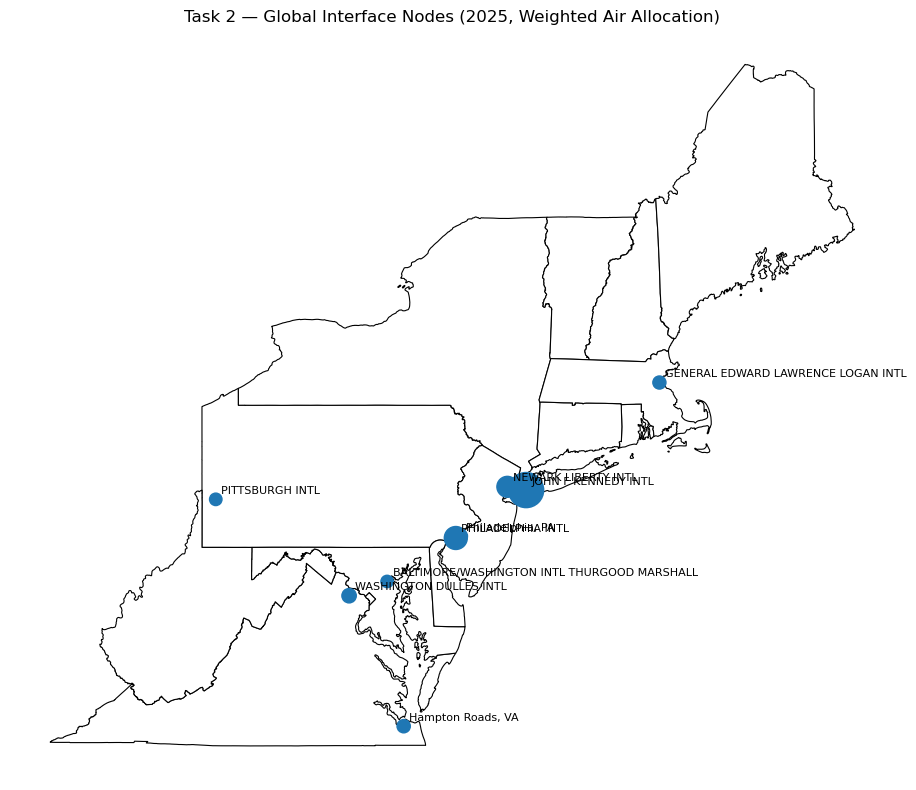

In [97]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

ne_states_map = states[states["STUSPS"].isin(northeast_states)].copy()

global_coords = pd.concat([
    final_global_seaports[["node_name", "latitude", "longitude"]],
    global_air_throughput_weighted[["node_name", "latitude", "longitude"]]
], ignore_index=True)

global_map_df = global_summary_final_weighted.copy()
global_map_df = global_map_df.merge(global_coords, on="node_name", how="left")

global_gdf = gpd.GeoDataFrame(
    global_map_df,
    geometry=gpd.points_from_xy(global_map_df["longitude"], global_map_df["latitude"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(11, 8))
ne_states_map.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

global_gdf.plot(
    ax=ax,
    markersize=global_gdf["tons_2025"] / global_gdf["tons_2025"].max() * 600 + 40
)

for _, row in global_gdf.iterrows():
    ax.annotate(
        row["node_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Task 2 — Global Interface Nodes (2025, Weighted Air Allocation)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("task2_global_interface_map_weighted.png", dpi=300, bbox_inches="tight")
plt.show()

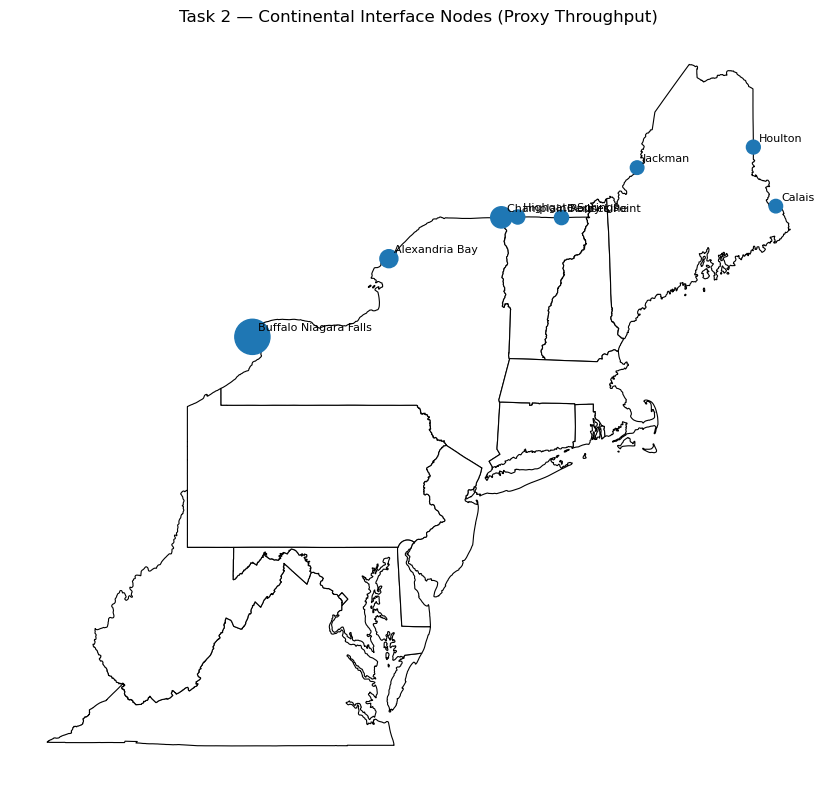

In [98]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Northeast state basemap
ne_states_map = states[states["STUSPS"].isin(northeast_states)].copy()

continental_map_df = continental_summary_final.copy()
continental_map_df["latitude"] = continental_map_df["node_name"].map(
    dict(zip(final_continental_nodes["node_name"], final_continental_nodes["latitude"]))
)
continental_map_df["longitude"] = continental_map_df["node_name"].map(
    dict(zip(final_continental_nodes["node_name"], final_continental_nodes["longitude"]))
)

continental_gdf = gpd.GeoDataFrame(
    continental_map_df,
    geometry=gpd.points_from_xy(continental_map_df["longitude"], continental_map_df["latitude"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(11, 8))
ne_states_map.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)

continental_gdf.plot(
    ax=ax,
    markersize=continental_gdf["tons_2025"] / continental_gdf["tons_2025"].max() * 600 + 40
)

for _, row in continental_gdf.iterrows():
    ax.annotate(
        row["node_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title("Task 2 — Continental Interface Nodes (Proxy Throughput)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("task2_continental_interface_map.png", dpi=300, bbox_inches="tight")
plt.show()

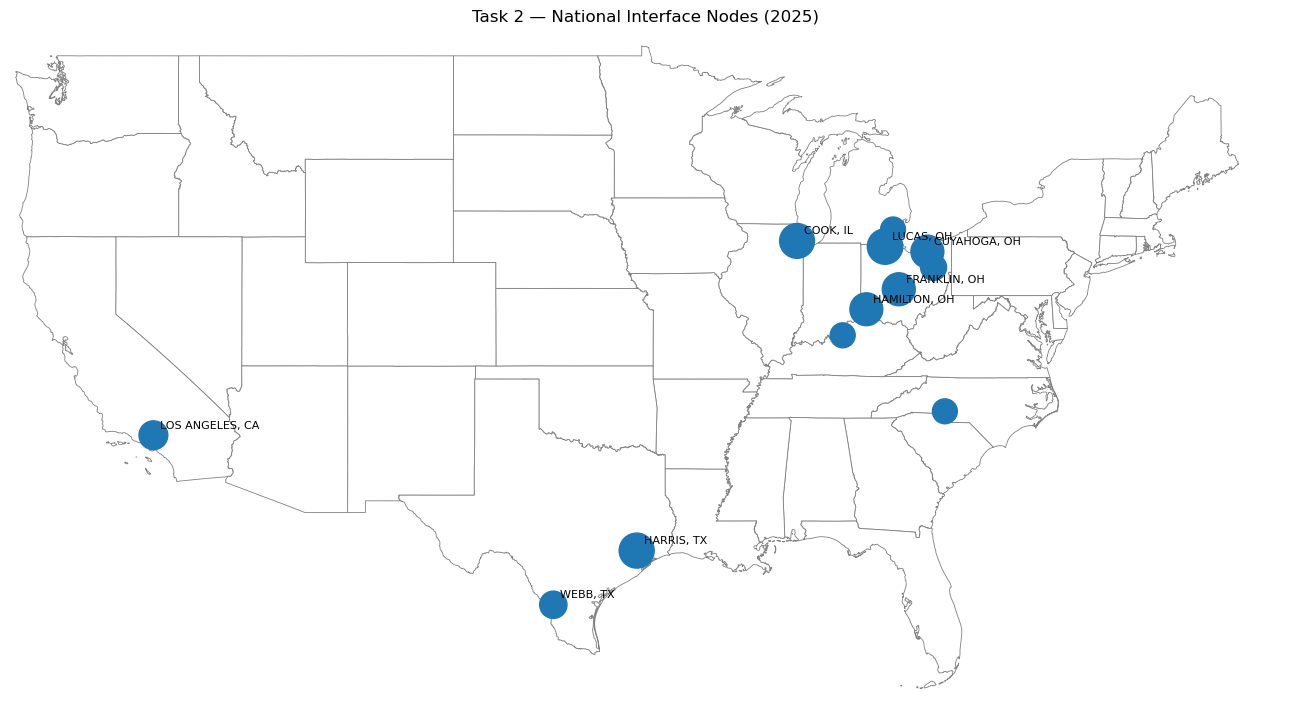

In [99]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Project counties first, then compute centroids
counties_proj = counties.to_crs("EPSG:5070").copy()
counties_proj["centroid"] = counties_proj.geometry.centroid

# Convert centroids back to WGS84
centroids_gdf = gpd.GeoDataFrame(
    counties_proj[["GEOID"]],
    geometry=counties_proj["centroid"],
    crs="EPSG:5070"
).to_crs("EPSG:4326")

centroids_gdf["centroid_lon"] = centroids_gdf.geometry.x
centroids_gdf["centroid_lat"] = centroids_gdf.geometry.y

county_centroids_small = centroids_gdf[["GEOID", "centroid_lat", "centroid_lon"]].copy()

national_map_df = final_national_nodes.copy()
national_map_df = national_map_df.merge(
    county_centroids_small,
    left_on="county_fips",
    right_on="GEOID",
    how="left"
)

national_gdf = gpd.GeoDataFrame(
    national_map_df,
    geometry=gpd.points_from_xy(national_map_df["centroid_lon"], national_map_df["centroid_lat"]),
    crs="EPSG:4326"
)

states_map = states[~states["STUSPS"].isin(["AK", "HI", "PR"])].copy()

fig, ax = plt.subplots(figsize=(13, 8))
states_map.plot(ax=ax, color="white", edgecolor="gray", linewidth=0.6)

national_gdf.plot(
    ax=ax,
    markersize=national_gdf["tons_2025"] / national_gdf["tons_2025"].max() * 600 + 50
)

# Label only top 8 to avoid clutter
top_labels = national_gdf.nlargest(8, "tons_2025")

for _, row in top_labels.iterrows():
    ax.annotate(
        row["node_name"],
        (row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)

ax.set_title("Task 2 — National Interface Nodes (2025)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("task2_national_interface_map_corrected.png", dpi=300, bbox_inches="tight")
plt.show()